# 2. The Artificial Neural Network Architecture
---
In this notebook, The idea is to build up from a **single neuron** to a full **multilayer perceptron (MLP)**.

## What is a Neural Network

A neural network is a machine learning model that stacks simple "neurons" in layers and learns pattern-recognizing weights and biases from data to map inputs to outputs.

Neural networks are among the most influential algorithms in **modern machine learning and artificial intelligence (AI)**. They underpin breakthroughs in computer vision, natural language processing (NLP), speech recognition and countless real-world applications ranging from forecasting to facial recognition. (IBM)

### How do neural networks work?

On a high level, the inspiration for neural networks comes from the biological neurons in the human brain, which communicate through electrical signals.

<img src="./Images/annnn_img.webp" width="800" height="800" />

A neural network can be understood through a simple example: spam detection. An email is fed into the network, and features such as words or phrases like “prize,” “money,” “dear” or “win” are used as inputs. The early neurons in the network process the importance of each signal, while later layers combine this information into higher-level cues that capture context and tone. The final layer then computes a probability of whether the email is spam, and if that probability is high enough, the email is flagged. In essence, the network learns how to transform raw features into meaningful patterns and use them to make predictions.


Mathematically, a neural network learns a function  f(X) by mapping an input vector X =(x1,x2,x3...) to a predict a response  Y.

A neural network is comprised of:

#### Input layer:
holds the raw features -- (X1, X2 , X3 , ..).

#### Hidden layers: 
consist of artificial neurons (or nodes) that transform inputs into new representations. 
Mathematically, hidden layers are expressed as the input features, multiplied by their associated weights and added bias to pass from one layer to the next layer, eventually arriving at the final output layer. 
This is where the linear transformation between input and output happens. 

#### Output layer: 
After performing the linear transformation in the hidden layer, a nonlinear activation function (tanh, sigmoid, ReLU ) is added to produce the final prediction (such as a number for regression, or a probability distribution for classification).  

## 2.1 From Logistic Regression to a Single Neuron

You already know **logistic regression**:

$$\hat{y} = w_1 x_1 + w_2 x_2 + b$$

A single artificial neuron does **exactly this**:
- Takes inputs $x_1, x_2, \ldots$
- Multiplies by weights $w_1, w_2, \ldots$
- Adds a bias $b$
- Passes through an **activation function** $f$

$$\text{output} = f\left(\sum_i w_i x_i + b\right)$$

The only difference from logistic regression: we can swap the activation function!


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A single neuron — forward pass
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def single_neuron(x, w, b, activation=sigmoid):
    z = np.dot(w, x) + b   # weighted sum
    return activation(z)    # activation

# Example: 3 inputs
x = np.array([0.5, -1.2, 0.8])   # input features
w = np.array([0.4,  0.9, -0.3])  # weights
b = 0.1                           # bias

z = np.dot(w, x) + b
output = sigmoid(z)

print("=== Single Neuron Forward Pass ===")
print(f"Inputs   x = {x}")
print(f"Weights  w = {w}")
print(f"Bias     b = {b}")
print(f"z = w·x + b = {z:.4f}")
print(f"output = σ(z) = {output:.4f}")


=== Single Neuron Forward Pass ===
Inputs   x = [ 0.5 -1.2  0.8]
Weights  w = [ 0.4  0.9 -0.3]
Bias     b = 0.1
z = w·x + b = -1.0200
output = σ(z) = 0.2650


## 2.2 Visualizing a Single Neuron

```
        x₁ ──(w₁)──┐
        x₂ ──(w₂)──┤──[ Σ + b ]──[ f(·) ]──► output
        x₃ ──(w₃)──┘
```

The neuron:
1. **Receives** inputs
2. **Weights** them (some matter more than others)
3. **Sums** them plus a bias
4. **Activates** — applies a non-linear function


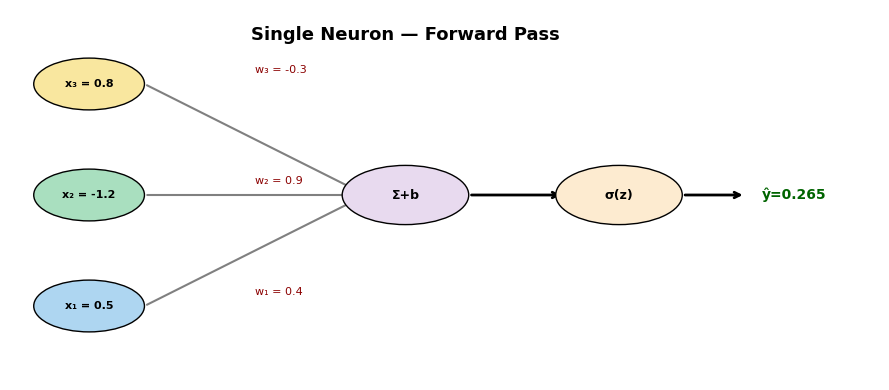

In [2]:
# Visualizing the neuron diagram
fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')

# Input nodes
inputs = ['x₁ = 0.5', 'x₂ = -1.2', 'x₃ = 0.8']
weights = ['w₁ = 0.4', 'w₂ = 0.9', 'w₃ = -0.3']
colors = ['#AED6F1', '#A9DFBF', '#F9E79F']

for i, (inp, wt, col) in enumerate(zip(inputs, weights, colors)):
    y_pos = 0.2 + i * 0.3
    circle = plt.Circle((0.1, y_pos), 0.07, color=col, ec='black', zorder=3)
    ax.add_patch(circle)
    ax.text(0.1, y_pos, inp, ha='center', va='center', fontsize=8, fontweight='bold')
    ax.annotate("", xy=(0.45, 0.5), xytext=(0.17, y_pos),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.text(0.31, y_pos + 0.03, wt, fontsize=8, color='darkred')

# Sum node
sum_circle = plt.Circle((0.5, 0.5), 0.08, color='#E8DAEF', ec='black', zorder=3)
ax.add_patch(sum_circle)
ax.text(0.5, 0.5, 'Σ+b', ha='center', va='center', fontsize=9, fontweight='bold')

# Activation
ax.annotate("", xy=(0.7, 0.5), xytext=(0.58, 0.5),
            arrowprops=dict(arrowstyle='->', lw=2))
act_circle = plt.Circle((0.77, 0.5), 0.08, color='#FDEBD0', ec='black', zorder=3)
ax.add_patch(act_circle)
ax.text(0.77, 0.5, 'σ(z)', ha='center', va='center', fontsize=9, fontweight='bold')

# Output
ax.annotate("", xy=(0.93, 0.5), xytext=(0.85, 0.5),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.text(0.95, 0.5, f'ŷ={output:.3f}', ha='left', va='center', fontsize=10, color='darkgreen', fontweight='bold')

ax.text(0.5, 0.92, 'Single Neuron — Forward Pass', ha='center', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 2.3 Stacking Neurons: Layers

When we stack many neurons in **layers**, we get a **Multilayer Perceptron (MLP)**:

```
INPUT LAYER     HIDDEN LAYER     OUTPUT LAYER
   x₁  ──────►  h₁  ──────►
   x₂  ──────►  h₂  ──────►  ŷ
   x₃  ──────►  h₃  ──────►
```

- **Input layer:** raw features (no computation, just passes data in)
- **Hidden layer(s):** where the learning happens
- **Output layer:** final prediction

Every neuron in one layer is connected to **every neuron** in the next layer → called a **fully connected** or **dense** layer.

<img src="./Images/fully_connected.png" width="800" height="800" />

In [3]:
# Building a 2-layer MLP from scratch with NumPy
np.random.seed(42)

# Network: 2 inputs → 3 hidden neurons → 1 output
# Random weights (we'll learn how to initialize properly later)
W1 = np.random.randn(3, 2) * 0.5  # shape: (hidden_size, input_size)
b1 = np.zeros(3)                   # shape: (hidden_size,)
W2 = np.random.randn(1, 3) * 0.5  # shape: (output_size, hidden_size)
b2 = np.zeros(1)                   # shape: (output_size,)

print("Network architecture: 2 → 3 → 1")
print(f"W1 shape: {W1.shape}  (3 hidden neurons, each sees 2 inputs)")
print(f"b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}  (1 output neuron, sees 3 hidden neurons)")
print(f"b2 shape: {b2.shape}")
print(f"\nTotal parameters: {W1.size + b1.size + W2.size + b2.size}")

# Forward pass on one sample
x = np.array([0.5, -1.2])

# Hidden layer
z1 = W1 @ x + b1       # linear step
a1 = sigmoid(z1)       # activation

# Output layer
z2 = W2 @ a1 + b2
a2 = sigmoid(z2)

print(f"\n=== Forward Pass ===")
print(f"Input:         {x}")
print(f"Hidden z1:     {np.round(z1,3)}")
print(f"Hidden a1:     {np.round(a1,3)}")
print(f"Output z2:     {np.round(z2,3)}")
print(f"Output a2:     {np.round(a2,3)}  ← prediction")


Network architecture: 2 → 3 → 1
W1 shape: (3, 2)  (3 hidden neurons, each sees 2 inputs)
b1 shape: (3,)
W2 shape: (1, 3)  (1 output neuron, sees 3 hidden neurons)
b2 shape: (1,)

Total parameters: 13

=== Forward Pass ===
Input:         [ 0.5 -1.2]
Hidden z1:     [ 0.207 -0.752  0.082]
Hidden a1:     [0.552 0.32  0.52 ]
Output z2:     [0.436]
Output a2:     [0.607]  ← prediction


> 💡 In practice, **2–5 hidden layers** with **64–512 neurons** handles most problems.

In [4]:
# Comparing parameter counts for different architectures
def count_params(layers):
    total = 0
    for i in range(len(layers)-1):
        total += layers[i] * layers[i+1] + layers[i+1]  # weights + biases
    return total

architectures = {
    "Shallow & wide  [2→256→1]":   [2, 256, 1],
    "Deep & narrow   [2→8→8→8→1]": [2, 8, 8, 8, 1],
    "Balanced        [2→64→32→1]": [2, 64, 32, 1],
    "Very deep       [2→16×5→1]":  [2,16,16,16,16,16,1],
}

print(f"{'Architecture':<35} {'Params':>8}")
print("-" * 45)
for name, arch in architectures.items():
    print(f"{name:<35} {count_params(arch):>8,}")


Architecture                          Params
---------------------------------------------
Shallow & wide  [2→256→1]              1,025
Deep & narrow   [2→8→8→8→1]              177
Balanced        [2→64→32→1]            2,305
Very deep       [2→16×5→1]             1,153


## ✏️ Exercise

1. For a network with layers `[3, 4, 2]`, how many weights and biases are there? Verify with the `count_params` function.
